# Customer Segmentation Analysis using Clustering

## 1. Library Imports and Setup

Setting up the required libraries for data manipulation, visualization, and machine learning algorithms.

In [144]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Set visualization style
sns.set(style="whitegrid")
plt.style.use('ggplot')

print("Libraries imported successfully!")

Libraries imported successfully!


## 2. Data Loading and Preprocessing

In [145]:
# Load the dataset
df_path = 'data/Online_Retail.xlsx'
df = pd.read_excel(df_path, dtype={'InvoiceNo': str, 'StockCode': str})
print(f"Dataset loaded successfully: {df.shape[0]:,} rows × {df.shape[1]} columns")

# Data cleaning steps
df.dropna(subset=['CustomerID'], inplace=True)
df['CustomerID'] = df['CustomerID'].astype(int)

# Filter for UK transactions only
df_uk = df[df['Country'] == 'United Kingdom'].copy()

# Remove cancelled orders (InvoiceNo starting with 'C')
df_uk = df_uk[~df_uk['InvoiceNo'].str.startswith('C', na=False)]

# Remove invalid transactions
df_uk = df_uk[(df_uk['Quantity'] > 0) & (df_uk['UnitPrice'] > 0)]

# Prepare date and price columns
df_uk['InvoiceDate'] = pd.to_datetime(df_uk['InvoiceDate'])
df_uk['TotalPrice'] = df_uk['Quantity'] * df_uk['UnitPrice']

print(f"Data cleaning completed: {df_uk.shape[0]:,} valid transactions retained")
print(f"Unique customers: {df_uk['CustomerID'].nunique():,}")
print(f"Date range: {df_uk['InvoiceDate'].min().date()} to {df_uk['InvoiceDate'].max().date()}")

# Display sample of cleaned data
print("\nSample of cleaned data:")
display(df_uk.head(3))

Dataset loaded successfully: 541,909 rows × 8 columns
Data cleaning completed: 354,321 valid transactions retained
Unique customers: 3,920
Date range: 2010-12-01 to 2011-12-09

Sample of cleaned data:
Data cleaning completed: 354,321 valid transactions retained
Unique customers: 3,920
Date range: 2010-12-01 to 2011-12-09

Sample of cleaned data:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00


## 3. RFM Analysis

In [146]:
# Calculate RFM metrics
snapshot_date = df_uk['InvoiceDate'].max() + pd.Timedelta(days=1)
print(f"Reference date for Recency calculation: {snapshot_date.date()}")

rfm = df_uk.groupby('CustomerID').agg({
    'InvoiceDate': lambda date: (snapshot_date - date.max()).days,
    'InvoiceNo': 'nunique',
    'TotalPrice': 'sum'
}).rename(columns={
    'InvoiceDate': 'Recency',
    'InvoiceNo': 'Frequency', 
    'TotalPrice': 'Monetary'
})

print(f"RFM metrics calculated for {len(rfm):,} customers")
print("\nRFM Summary Statistics:")
display(rfm.describe().round(2))

print("\nSample RFM data:")
display(rfm.head())

Reference date for Recency calculation: 2011-12-10
RFM metrics calculated for 3,920 customers

RFM Summary Statistics:


,Recency,Frequency,Monetary
count,3920.00,3920.00,3920.00
mean,92.21,4.25,1864.39
std,99.53,7.20,7482.82
min,1.00,1.00,3.75
25%,18.00,1.00,300.28
50%,51.00,2.00,652.28
75%,143.00,5.00,1576.58
max,374.00,209.00,259657.30



Sample RFM data:


,Recency,Frequency,Monetary
CustomerID,,,
12346,326,1,77183.60
12747,2,11,4196.01
12748,1,209,33719.73
12749,4,5,4090.88
12820,3,4,942.34


### 3.1 RFM Distribution Analysis

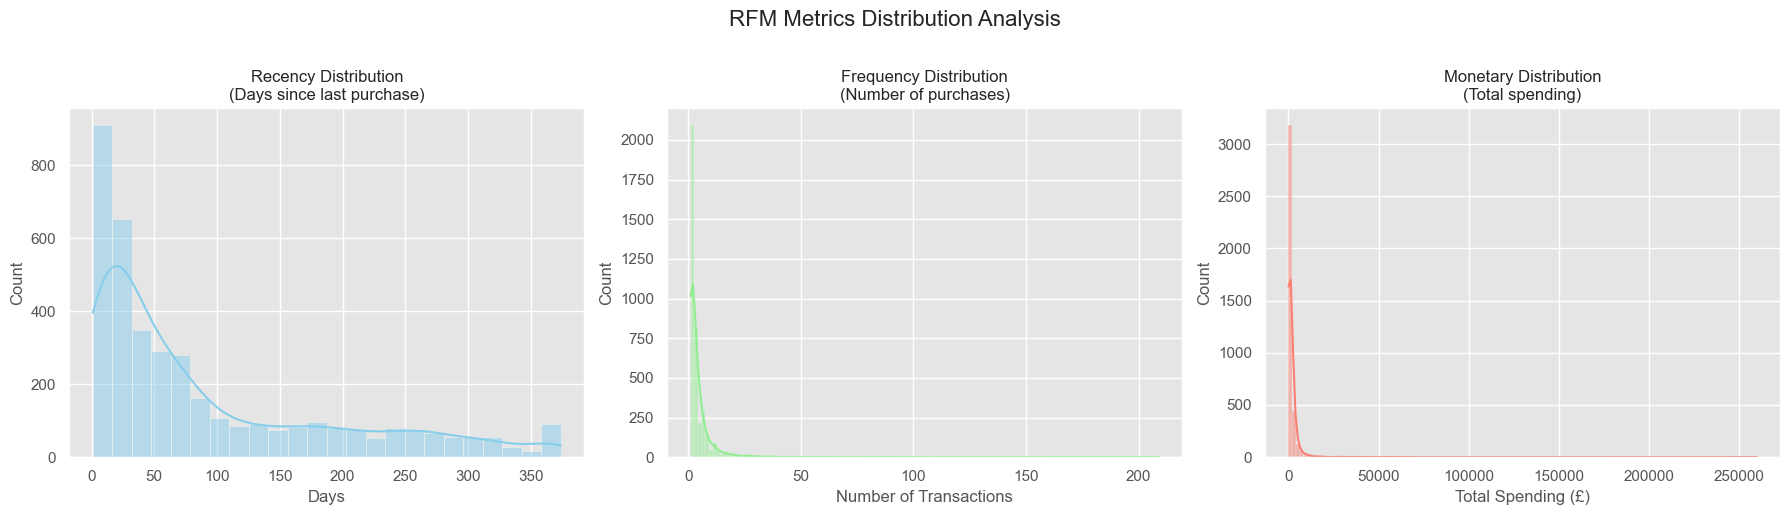

In [147]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(rfm['Recency'], ax=axes[0], kde=True, color='skyblue')
axes[0].set_title('Recency Distribution\n(Days since last purchase)', fontsize=12)
axes[0].set_xlabel('Days')

sns.histplot(rfm['Frequency'], ax=axes[1], kde=True, color='lightgreen')  
axes[1].set_title('Frequency Distribution\n(Number of purchases)', fontsize=12)
axes[1].set_xlabel('Number of Transactions')

sns.histplot(rfm['Monetary'], ax=axes[2], kde=True, color='salmon')
axes[2].set_title('Monetary Distribution\n(Total spending)', fontsize=12) 
axes[2].set_xlabel('Total Spending (£)')

plt.suptitle('RFM Metrics Distribution Analysis', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

## 4. Data Preprocessing for Clustering

### 4.1 Data Scaling

In [148]:
from sklearn.preprocessing import StandardScaler

# Standardize RFM features
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm)
rfm_scaled_df = pd.DataFrame(rfm_scaled, index=rfm.index, columns=rfm.columns)

print("RFM data standardized successfully")
print(f"Scaled data shape: {rfm_scaled_df.shape}")
print("\nStandardized RFM Statistics:")
display(rfm_scaled_df.describe().round(3))

print("\nSample of scaled data:")
display(rfm_scaled_df.head(3))

RFM data standardized successfully
Scaled data shape: (3920, 3)

Standardized RFM Statistics:


,Recency,Frequency,Monetary
count,3920.000,3920.000,3920.000
mean,-0.000,0.000,0.000
std,1.000,1.000,1.000
min,-0.916,-0.451,-0.249
25%,-0.746,-0.451,-0.209
50%,-0.414,-0.312,-0.162
75%,0.510,0.105,-0.038
max,2.831,28.445,34.456



Sample of scaled data:


,Recency,Frequency,Monetary
CustomerID,,,
12346,2.349165,-0.451000,10.066906
12747,-0.906425,0.938220,0.311637
12748,-0.916473,28.444775,4.257675


## 5. Clustering Analysis

### 5.1 K-Means Clustering

#### 5.1.1 Finding Optimal Number of Clusters

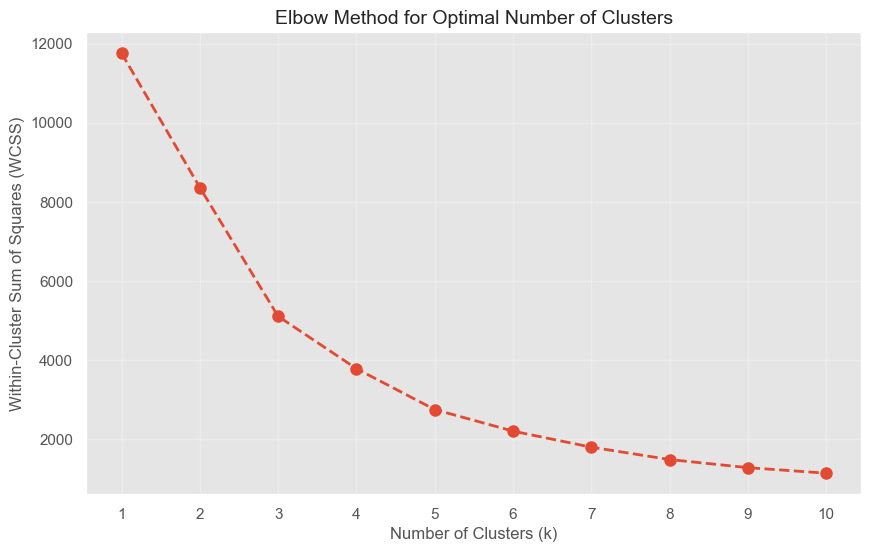

Elbow method suggests optimal k around 3-4 clusters


In [149]:
from sklearn.cluster import KMeans

# Calculate WCSS for different number of clusters
wcss = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(rfm_scaled_df)
    wcss.append(kmeans.inertia_)

# Create Elbow Method visualization
plt.figure(figsize=(10, 6))
plt.plot(k_range, wcss, marker='o', linestyle='--', linewidth=2, markersize=8)
plt.title('Elbow Method for Optimal Number of Clusters', fontsize=14)
plt.xlabel('Number of Clusters (k)', fontsize=12)
plt.ylabel('Within-Cluster Sum of Squares (WCSS)', fontsize=12)
plt.xticks(k_range)
plt.grid(True, alpha=0.3)
plt.show()

print("Elbow method suggests optimal k around 3-4 clusters")

#### 5.1.2 K-Means Results

In [150]:
# Apply K-Means with optimal k=3
optimal_k = 3
kmeans = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(rfm_scaled_df)

# Add cluster labels to original RFM data
rfm_with_clusters = rfm.copy()
rfm_with_clusters['Cluster'] = cluster_labels

# Calculate cluster characteristics
cluster_summary = rfm_with_clusters.groupby('Cluster').agg({
    'Recency': ['mean', 'count'],
    'Frequency': 'mean', 
    'Monetary': 'mean'
}).round(2)

# Flatten column names
cluster_summary.columns = ['Avg_Recency', 'Customer_Count', 'Avg_Frequency', 'Avg_Monetary']

print(f"K-Means clustering completed with {optimal_k} clusters")
print("\nCluster Characteristics:")
display(cluster_summary)

K-Means clustering completed with 3 clusters

Cluster Characteristics:


,Avg_Recency,Customer_Count,Avg_Frequency,Avg_Monetary
Cluster,,,,
0,40.75,2901,4.72,1785.03
1,243.78,996,1.59,487.60
2,19.39,23,59.91,71494.41


### 5.2 Hierarchical Clustering

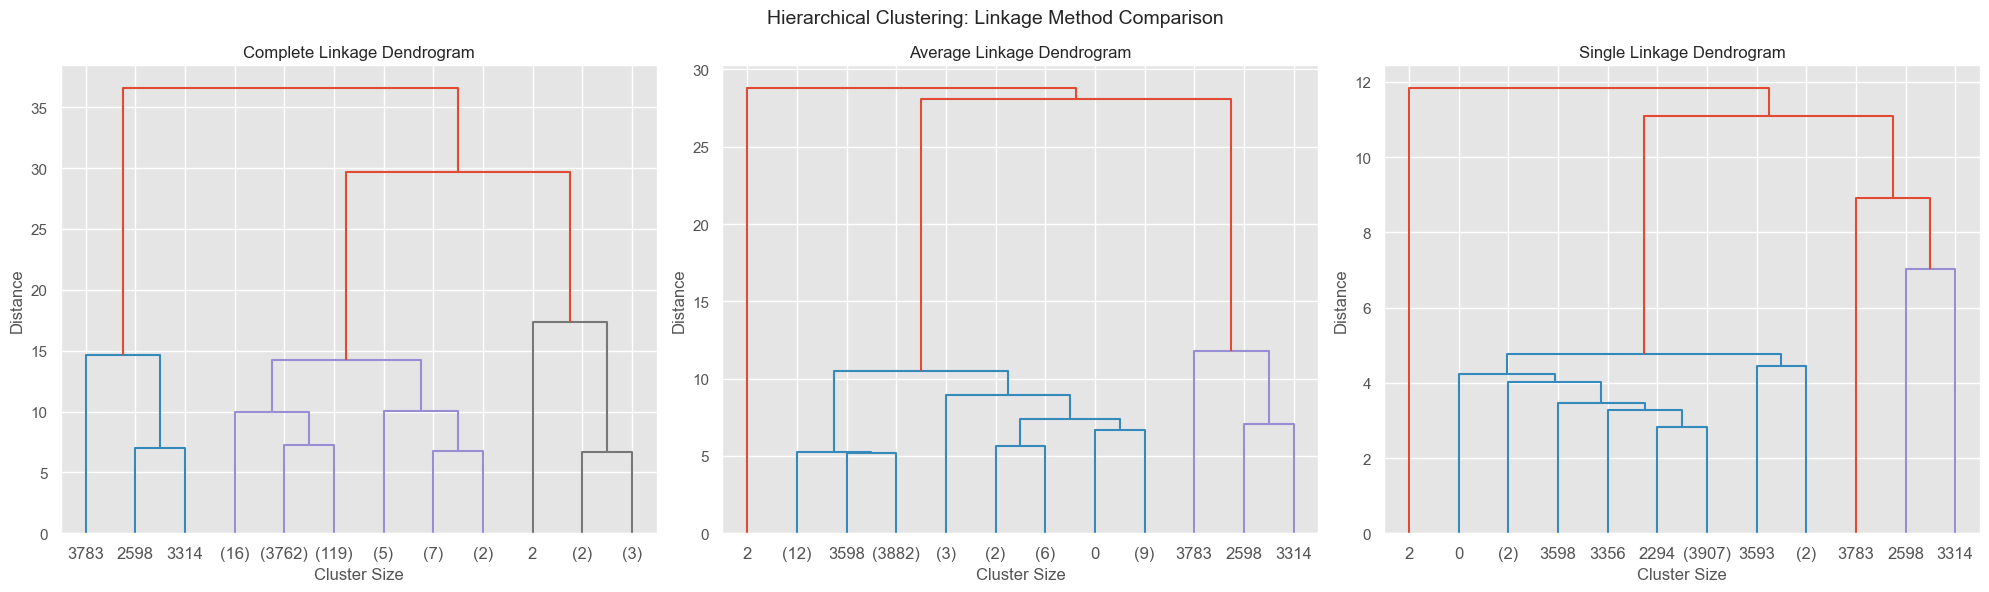

Complete linkage shows clearest cluster separation at distance ~15


In [151]:
from scipy.cluster.hierarchy import dendrogram, linkage

# Create dendrograms for different linkage methods
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

linkage_methods = ['complete', 'average', 'single']
linkage_data = {}

for i, method in enumerate(linkage_methods):
    # Calculate linkage matrix
    linked = linkage(rfm_scaled_df, method=method)
    linkage_data[method] = linked
    
    # Create dendrogram
    dendrogram(linked, ax=axes[i], truncate_mode='lastp', p=12, 
               show_leaf_counts=True)
    axes[i].set_title(f'{method.capitalize()} Linkage Dendrogram', fontsize=12)
    axes[i].set_xlabel('Cluster Size')
    axes[i].set_ylabel('Distance')

plt.suptitle('Hierarchical Clustering: Linkage Method Comparison', fontsize=14)
plt.tight_layout()
plt.show()

print("Complete linkage shows clearest cluster separation at distance ~15")

#### Hierarchical Clustering Results

In [152]:
from sklearn.cluster import AgglomerativeClustering

# Apply hierarchical clustering with complete linkage
agg_cluster = AgglomerativeClustering(n_clusters=4, linkage='complete')
hierarchical_labels = agg_cluster.fit_predict(rfm_scaled_df)

# Add hierarchical cluster labels to RFM data
rfm_with_hierarchical = rfm.copy()
rfm_with_hierarchical['Hierarchical_Cluster'] = hierarchical_labels

# Calculate hierarchical cluster characteristics
hierarchical_summary = rfm_with_hierarchical.groupby('Hierarchical_Cluster').agg({
    'Recency': ['mean', 'count'],
    'Frequency': 'mean',
    'Monetary': 'mean'
}).round(2)

# Flatten column names
hierarchical_summary.columns = ['Avg_Recency', 'Customer_Count', 'Avg_Frequency', 'Avg_Monetary']

print("Hierarchical clustering completed with 4 clusters (Complete linkage)")
print("\nHierarchical Cluster Characteristics:")
display(hierarchical_summary)

Hierarchical clustering completed with 4 clusters (Complete linkage)

Hierarchical Cluster Characteristics:


,Avg_Recency,Customer_Count,Avg_Frequency,Avg_Monetary
Hierarchical_Cluster,,,,
0,3.33,3,36.00,207560.20
1,2.20,5,98.20,36786.37
2,92.41,3911,4.05,1653.81
3,1.00,1,209.00,33719.73


### 5.3 DBSCAN Clustering

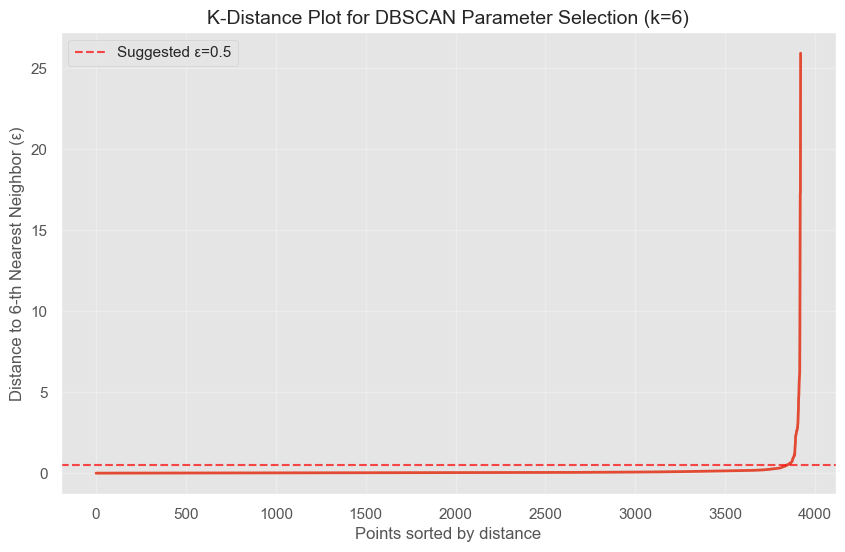

K-distance plot suggests ε ≈ 0.5 for DBSCAN


In [153]:
from sklearn.neighbors import NearestNeighbors

# Calculate k-distance plot for epsilon parameter selection
min_samples = 6  # 2 * number of features (RFM = 3 features)
neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors_fit = neighbors.fit(rfm_scaled_df)
distances, indices = neighbors_fit.kneighbors(rfm_scaled_df)

# Sort distances for k-distance plot
sorted_distances = np.sort(distances[:, min_samples-1])

plt.figure(figsize=(10, 6))
plt.plot(sorted_distances, linewidth=2)
plt.title(f'K-Distance Plot for DBSCAN Parameter Selection (k={min_samples})', fontsize=14)
plt.xlabel('Points sorted by distance', fontsize=12)
plt.ylabel(f'Distance to {min_samples}-th Nearest Neighbor (ε)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.axhline(y=0.5, color='red', linestyle='--', alpha=0.7, label='Suggested ε=0.5')
plt.legend()
plt.show()

print("K-distance plot suggests ε ≈ 0.5 for DBSCAN")

#### DBSCAN Results

In [154]:
from sklearn.cluster import DBSCAN

# Apply DBSCAN clustering
eps = 0.5
min_samples = 5
dbscan = DBSCAN(eps=eps, min_samples=min_samples)
dbscan_labels = dbscan.fit_predict(rfm_scaled_df)

# Analyze DBSCAN results
n_clusters_ = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise_ = list(dbscan_labels).count(-1)

print(f"DBSCAN clustering completed:")
print(f" • Clusters found: {n_clusters_}")
print(f" • Noise points: {n_noise_:,} ({n_noise_/len(dbscan_labels)*100:.1f}%)")

# Add DBSCAN cluster labels to RFM data
rfm_with_dbscan = rfm.copy()
rfm_with_dbscan['DBSCAN_Cluster'] = dbscan_labels

# Calculate cluster characteristics (excluding noise points)
if n_clusters_ > 0:
    dbscan_summary = rfm_with_dbscan[rfm_with_dbscan['DBSCAN_Cluster'] != -1].groupby('DBSCAN_Cluster').agg({
        'Recency': ['mean', 'count'],
        'Frequency': 'mean',
        'Monetary': 'mean'
    }).round(2)
    
    # Flatten column names
    dbscan_summary.columns = ['Avg_Recency', 'Customer_Count', 'Avg_Frequency', 'Avg_Monetary']
    
    print("\nDBSCAN Cluster Characteristics (excluding noise):")
    display(dbscan_summary)
else:
    print("No clusters found - all points classified as noise")

DBSCAN clustering completed:
 • Clusters found: 2
 • Noise points: 52 (1.3%)

DBSCAN Cluster Characteristics (excluding noise):


,Avg_Recency,Customer_Count,Avg_Frequency,Avg_Monetary
DBSCAN_Cluster,,,,
0,92.95,3863,3.73,1302.51
1,2.60,5,37.40,7421.23


## 6. Cluster Visualization Comparison

### Principal Component Analysis (PCA) Visualization

In [155]:
# Perform hierarchical clustering with different linkage methods for visualization
from sklearn.cluster import AgglomerativeClustering

# Generate all hierarchical clustering labels
hier_ward = AgglomerativeClustering(n_clusters=4, linkage='ward').fit_predict(rfm_scaled_df)
hier_complete = AgglomerativeClustering(n_clusters=4, linkage='complete').fit_predict(rfm_scaled_df)
hier_average = AgglomerativeClustering(n_clusters=4, linkage='average').fit_predict(rfm_scaled_df)
hier_single = AgglomerativeClustering(n_clusters=4, linkage='single').fit_predict(rfm_scaled_df)

# Apply PCA for visualization
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
rfm_pca = pca.fit_transform(rfm_scaled_df)

print(f"PCA completed: {pca.explained_variance_ratio_.sum():.1%} of total variance explained")
print(f"PC1 explains {pca.explained_variance_ratio_[0]:.1%}, PC2 explains {pca.explained_variance_ratio_[1]:.1%}")

# Define beautiful color palettes for each method
color_palettes = {
    'K-Means': ['#FF6B6B', '#4ECDC4', '#45B7D1'],
    'Hierarchical - Ward': ['#96CEB4', '#FFEAA7', '#DDA0DD', '#98D8C8'], 
    'Hierarchical - Complete': ['#FF7675', '#74B9FF', '#FDCB6E', '#6C5CE7'],
    'Hierarchical - Average': ['#E17055', '#00B894', '#FDCB6E', '#A29BFE'],
    'Hierarchical - Single': ['#FD79A8', '#FDCB6E', '#6C5CE7', '#00CEC9'],
    'DBSCAN': ['#00B894', '#E17055', '#FDCB6E', '#6C5CE7']
}

# Prepare clustering results
clustering_results = [
    ('K-Means (k=3)', cluster_labels),
    ('Hierarchical - Ward', hier_ward),
    ('Hierarchical - Complete', hier_complete),
    ('Hierarchical - Average', hier_average),
    ('Hierarchical - Single', hier_single),
    ('DBSCAN', dbscan_labels)
]

print(f"\nCreating individual PCA visualizations for {len(clustering_results)} clustering methods...\n")

PCA completed: 84.4% of total variance explained
PC1 explains 54.6%, PC2 explains 29.8%

Creating individual PCA visualizations for 6 clustering methods...



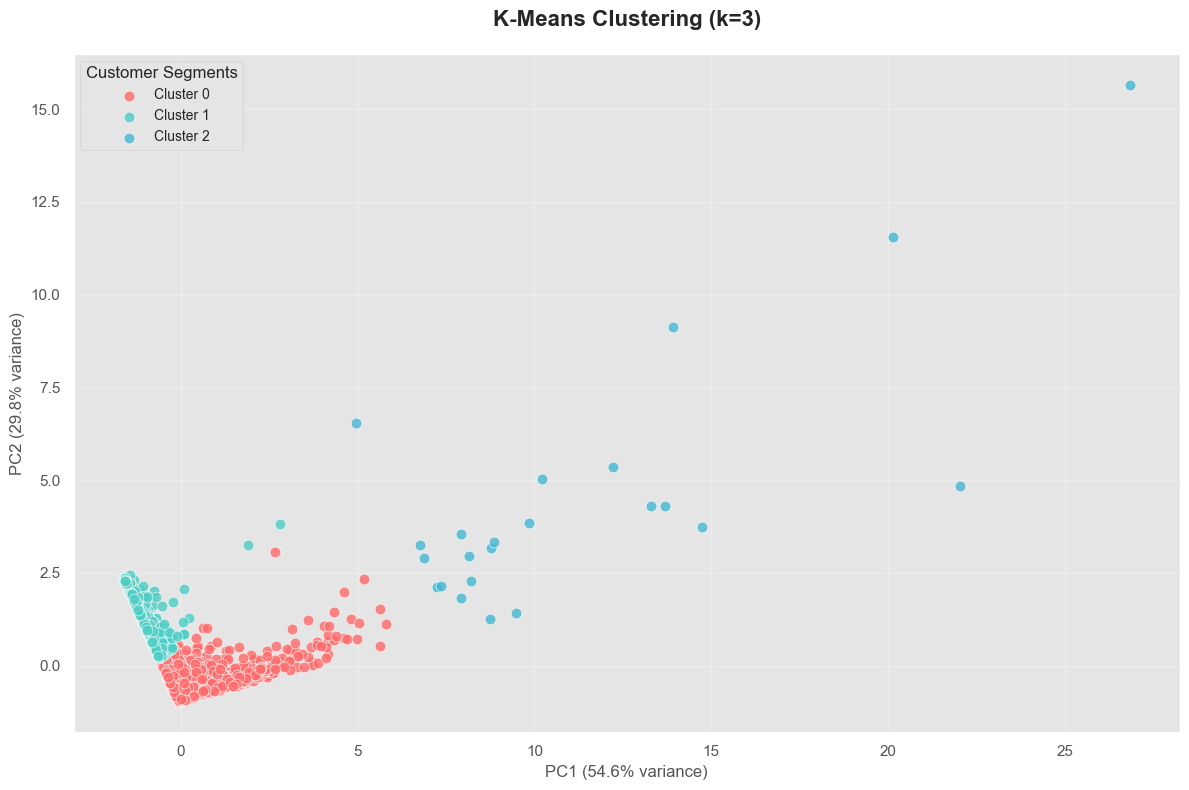

K-Means: 3 clusters | Customers per cluster: [2901, 996, 23]
────────────────────────────────────────────────────────────────────────────────


In [156]:
# 1. K-Means Visualization
plt.figure(figsize=(12, 8))
colors = color_palettes['K-Means']
for i, cluster in enumerate(np.unique(cluster_labels)):
    mask = cluster_labels == cluster
    plt.scatter(rfm_pca[mask, 0], rfm_pca[mask, 1], 
                c=colors[i % len(colors)], s=60, alpha=0.8, 
                label=f'Cluster {cluster}', edgecolors='white', linewidth=0.5)

plt.title('K-Means Clustering (k=3)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)', fontsize=12)
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)', fontsize=12)
plt.legend(title='Customer Segments', title_fontsize=12, fontsize=10, loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

n_customers_per_cluster = [sum(cluster_labels == i) for i in np.unique(cluster_labels)]
n_customers_per_cluster = [int(x) for x in n_customers_per_cluster]
print(f"K-Means: {len(np.unique(cluster_labels))} clusters | Customers per cluster: {n_customers_per_cluster}")
print("─" * 80)

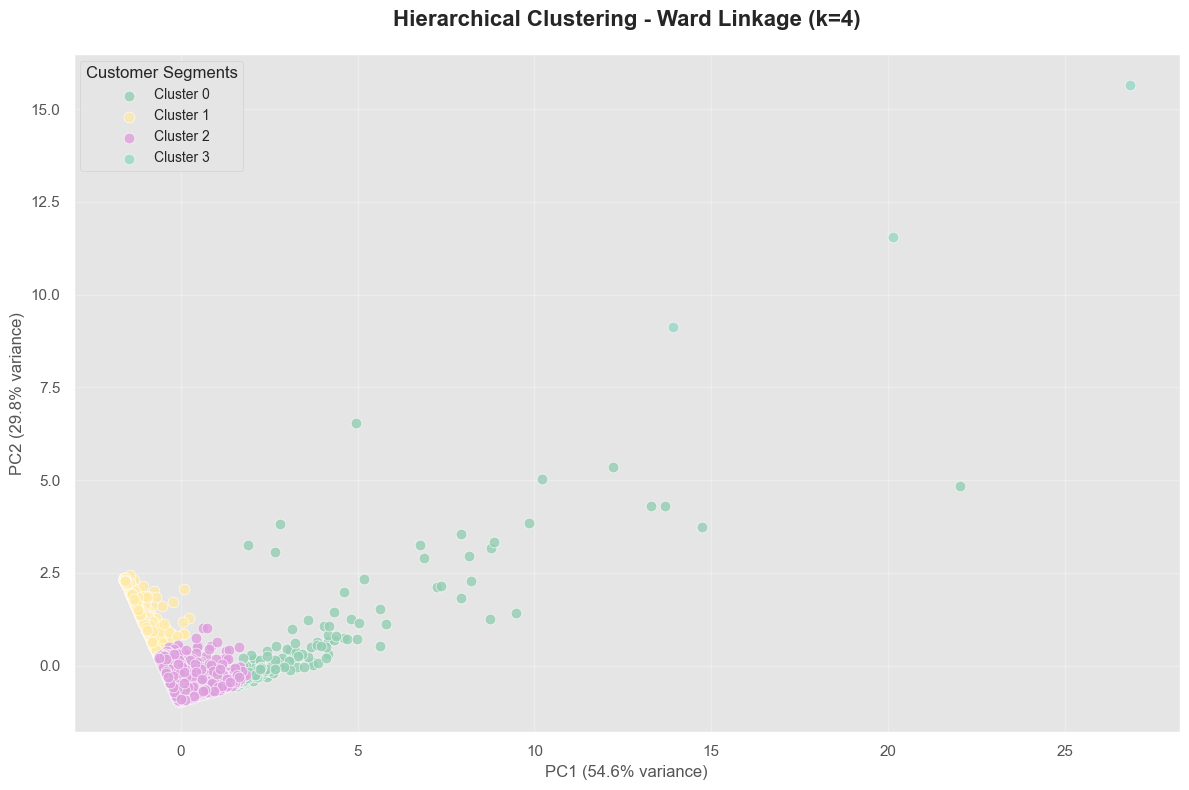

Hierarchical-Ward: 4 clusters | Customers per cluster: [166, 978, 2773, 3]
────────────────────────────────────────────────────────────────────────────────


In [157]:
# 2. Hierarchical Clustering - Ward Linkage
plt.figure(figsize=(12, 8))
colors = color_palettes['Hierarchical - Ward']
for i, cluster in enumerate(np.unique(hier_ward)):
    mask = hier_ward == cluster
    plt.scatter(rfm_pca[mask, 0], rfm_pca[mask, 1], 
                c=colors[i % len(colors)], s=60, alpha=0.8, 
                label=f'Cluster {cluster}', edgecolors='white', linewidth=0.5)

plt.title('Hierarchical Clustering - Ward Linkage (k=4)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)', fontsize=12)
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)', fontsize=12)
plt.legend(title='Customer Segments', title_fontsize=12, fontsize=10, loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

n_customers_per_cluster = [sum(hier_ward == i) for i in np.unique(hier_ward)]
n_customers_per_cluster = [int(sum(hier_ward == i)) for i in np.unique(hier_ward)]
print(f"Hierarchical-Ward: {len(np.unique(hier_ward))} clusters | Customers per cluster: {n_customers_per_cluster}")
print("─" * 80)

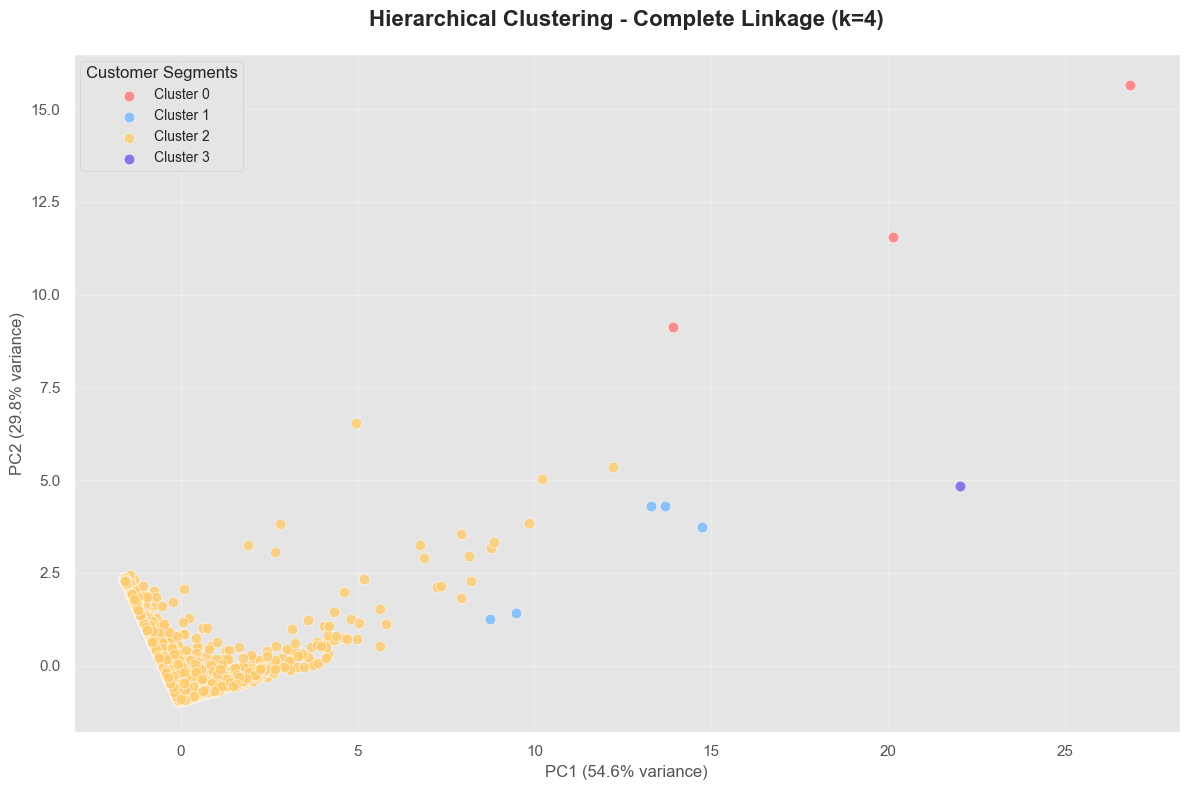

Hierarchical-Complete: 4 clusters | Customers per cluster: [3, 5, 3911, 1]
────────────────────────────────────────────────────────────────────────────────


In [158]:
# 3. Hierarchical Clustering - Complete Linkage
plt.figure(figsize=(12, 8))
colors = color_palettes['Hierarchical - Complete']
for i, cluster in enumerate(np.unique(hier_complete)):
    mask = hier_complete == cluster
    plt.scatter(rfm_pca[mask, 0], rfm_pca[mask, 1], 
                c=colors[i % len(colors)], s=60, alpha=0.8, 
                label=f'Cluster {cluster}', edgecolors='white', linewidth=0.5)

plt.title('Hierarchical Clustering - Complete Linkage (k=4)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)', fontsize=12)
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)', fontsize=12)
plt.legend(title='Customer Segments', title_fontsize=12, fontsize=10, loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

n_customers_per_cluster = [sum(hier_complete == i) for i in np.unique(hier_complete)]
n_customers_per_cluster = [int(x) for x in n_customers_per_cluster]
print(f"Hierarchical-Complete: {len(np.unique(hier_complete))} clusters | Customers per cluster: {n_customers_per_cluster}")
print("─" * 80)

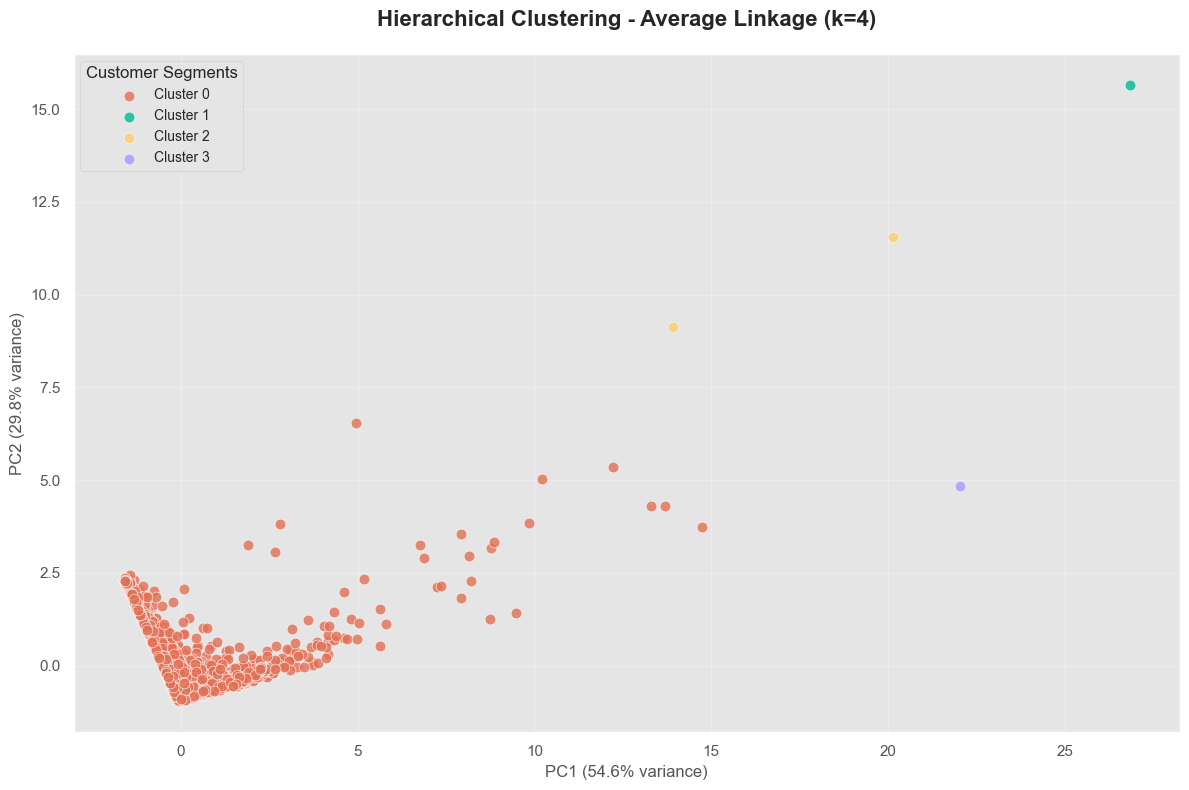

Hierarchical-Average: 4 clusters | Customers per cluster: [3916, 1, 2, 1]
────────────────────────────────────────────────────────────────────────────────


In [159]:
# 4. Hierarchical Clustering - Average Linkage  
plt.figure(figsize=(12, 8))
colors = color_palettes['Hierarchical - Average']
for i, cluster in enumerate(np.unique(hier_average)):
    mask = hier_average == cluster
    plt.scatter(rfm_pca[mask, 0], rfm_pca[mask, 1], 
                c=colors[i % len(colors)], s=60, alpha=0.8, 
                label=f'Cluster {cluster}', edgecolors='white', linewidth=0.5)

plt.title('Hierarchical Clustering - Average Linkage (k=4)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)', fontsize=12)
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)', fontsize=12)
plt.legend(title='Customer Segments', title_fontsize=12, fontsize=10, loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

n_customers_per_cluster = [sum(hier_average == i) for i in np.unique(hier_average)]
n_customers_per_cluster = [int(x) for x in n_customers_per_cluster]
print(f"Hierarchical-Average: {len(np.unique(hier_average))} clusters | Customers per cluster: {n_customers_per_cluster}")
print("─" * 80)

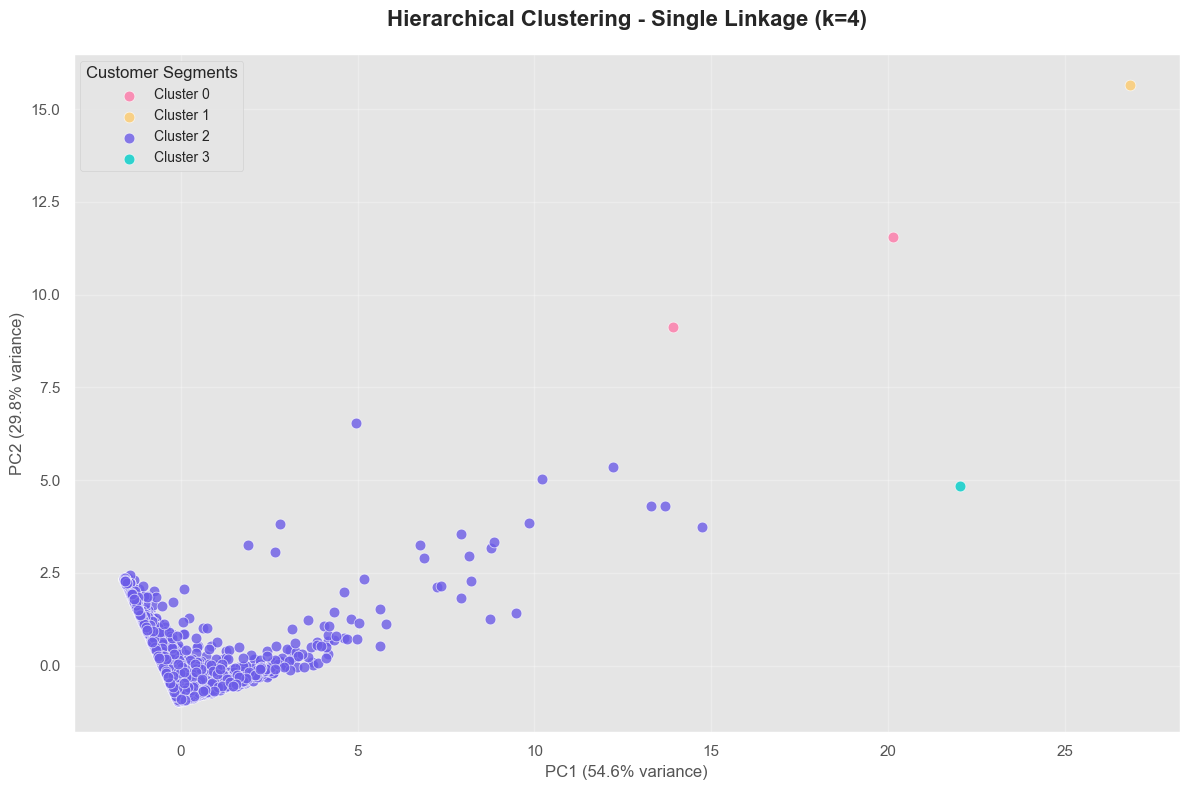

Hierarchical-Single: 4 clusters | Customers per cluster: [2, 1, 3916, 1]
────────────────────────────────────────────────────────────────────────────────


In [160]:
# 5. Hierarchical Clustering - Single Linkage
plt.figure(figsize=(12, 8))
colors = color_palettes['Hierarchical - Single']
for i, cluster in enumerate(np.unique(hier_single)):
    mask = hier_single == cluster
    plt.scatter(rfm_pca[mask, 0], rfm_pca[mask, 1], 
                c=colors[i % len(colors)], s=60, alpha=0.8, 
                label=f'Cluster {cluster}', edgecolors='white', linewidth=0.5)

plt.title('Hierarchical Clustering - Single Linkage (k=4)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)', fontsize=12)
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)', fontsize=12)
plt.legend(title='Customer Segments', title_fontsize=12, fontsize=10, loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

n_customers_per_cluster = [sum(hier_single == i) for i in np.unique(hier_single)]
n_customers_per_cluster = [int(x) for x in n_customers_per_cluster]
print(f"Hierarchical-Single: {len(np.unique(hier_single))} clusters | Customers per cluster: {n_customers_per_cluster}")
print("─" * 80)

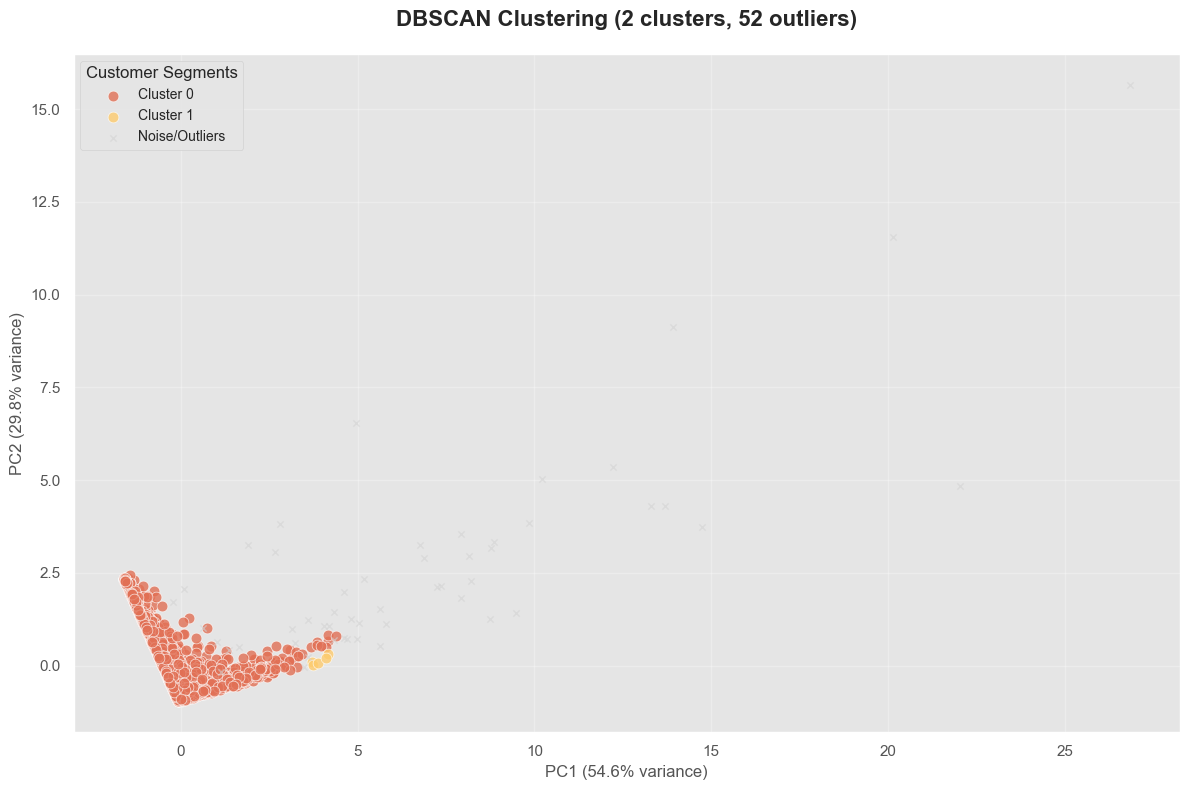

DBSCAN: 2 clusters | Customers per cluster: [3863, 5]
Outliers detected: 52 customers (1.3%)
────────────────────────────────────────────────────────────────────────────────


In [161]:
# 6. DBSCAN Visualization
plt.figure(figsize=(12, 8))
colors = color_palettes['DBSCAN']

# Plot regular clusters
unique_labels = np.unique(dbscan_labels)
n_clusters = len(unique_labels) - (1 if -1 in unique_labels else 0)

for i, cluster in enumerate(unique_labels):
    if cluster == -1:  # Skip noise points for now
        continue
    mask = dbscan_labels == cluster
    plt.scatter(rfm_pca[mask, 0], rfm_pca[mask, 1], 
                c=colors[i % len(colors)], s=60, alpha=0.8, 
                label=f'Cluster {cluster}', edgecolors='white', linewidth=0.5)

# Plot noise points separately
if -1 in unique_labels:
    noise_mask = dbscan_labels == -1
    plt.scatter(rfm_pca[noise_mask, 0], rfm_pca[noise_mask, 1], 
                c='lightgray', s=20, alpha=0.6, marker='x', 
                label='Noise/Outliers', linewidth=1)

n_noise = sum(dbscan_labels == -1) if -1 in unique_labels else 0
title_text = f'DBSCAN Clustering ({n_clusters} clusters'
if n_noise > 0:
    title_text += f', {n_noise} outliers)'
else:
    title_text += ')'

plt.title(title_text, fontsize=16, fontweight='bold', pad=20)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)', fontsize=12)
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)', fontsize=12)
plt.legend(title='Customer Segments', title_fontsize=12, fontsize=10, loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

cluster_counts = [sum(dbscan_labels == i) for i in unique_labels if i != -1]
cluster_counts = [int(sum(dbscan_labels == i)) for i in unique_labels if i != -1]
noise_count = sum(dbscan_labels == -1)
print(f"DBSCAN: {n_clusters} clusters | Customers per cluster: {cluster_counts}")
if noise_count > 0:
    print(f"Outliers detected: {noise_count:,} customers ({noise_count/len(dbscan_labels)*100:.1f}%)")
print("─" * 80)

## 6. Comprehensive Clustering Evaluation

### Evaluation Metrics Explanation:

**Silhouette Score**: Measures how similar an object is to its own cluster compared to other clusters
- Range: [-1, 1] | Higher is better | >0.5 is considered good

**Intra-cluster Distance**: Average distance between points within the same cluster  
- Lower values indicate more compact, cohesive clusters

**Inter-cluster Distance**: Average distance between points in different clusters
- Higher values indicate better separation between clusters

**Distance Ratio**: Inter-cluster distance divided by intra-cluster distance
- Higher ratios indicate better overall clustering quality

In [162]:
from sklearn.metrics import silhouette_score
from scipy.spatial.distance import pdist, cdist
import pandas as pd

def calculate_cluster_distances(data, labels):
    """Calculate average intra-cluster and inter-cluster distances."""
    unique_labels = np.unique(labels)
    intra_distances = []
    inter_distances = []
    
    for label in unique_labels:
        if label == -1:  # Skip noise points for DBSCAN
            continue
        cluster_points = data[labels == label]
        
        # Intra-cluster distance
        if len(cluster_points) > 1:
            intra_dist = np.mean(pdist(cluster_points))
        else:
            intra_dist = 0
        intra_distances.append(intra_dist)
        
        # Inter-cluster distance
        other_points = data[labels != label]
        if len(other_points) > 0:
            inter_dist = np.mean(cdist(cluster_points, other_points))
        else:
            inter_dist = 0
        inter_distances.append(inter_dist)
    
    return np.mean(intra_distances), np.mean(inter_distances)

def interpret_clusters(rfm_data, labels, method_name):
    """Generate business interpretations for clusters based on RFM values."""
    interpretations = {}
    unique_labels = np.unique(labels)
    
    for label in unique_labels:
        if label == -1:
            interpretations[label] = "Outliers - Unusual customer behavior"
            continue
            
        cluster_data = rfm_data[labels == label]
        avg_recency = cluster_data['Recency'].mean()
        avg_frequency = cluster_data['Frequency'].mean()
        avg_monetary = cluster_data['Monetary'].mean()
        
        # Business interpretation based on RFM values
        if avg_frequency > rfm['Frequency'].median() and avg_monetary > rfm['Monetary'].median():
            if avg_recency < rfm['Recency'].median():
                interpretation = "Champions - Best customers (High value, frequent, recent)"
            else:
                interpretation = "At Risk - High value but inactive recently"
        elif avg_frequency > rfm['Frequency'].median():
            if avg_recency < rfm['Recency'].median():
                interpretation = "Loyal Customers - Regular buyers"
            else:
                interpretation = "Cannot Lose Them - Frequent but not recent"
        elif avg_monetary > rfm['Monetary'].median():
            if avg_recency < rfm['Recency'].median():
                interpretation = "New Customers - High spenders, recent"
            else:
                interpretation = "Hibernating - High spenders but inactive"
        else:
            if avg_recency < rfm['Recency'].median():
                interpretation = "Potential Loyalists - Recent but low value"
            else:
                interpretation = "Lost - Low value and inactive"
        
        interpretations[label] = interpretation
    
    return interpretations

# Evaluate all hierarchical clustering methods
hierarchical_methods = ['ward', 'complete', 'average', 'single']
evaluation_results = {}

print("Evaluating all clustering methods...\n")

# Hierarchical clustering evaluation
for method in hierarchical_methods:
    try:
        hier_cluster = AgglomerativeClustering(n_clusters=4, linkage=method)
        hier_labels = hier_cluster.fit_predict(rfm_scaled_df)
        
        sil_score = silhouette_score(rfm_scaled_df, hier_labels)
        intra_dist, inter_dist = calculate_cluster_distances(rfm_scaled_df.values, hier_labels)
        interpretations = interpret_clusters(rfm, hier_labels, f"Hierarchical-{method}")
        
        evaluation_results[f"Hierarchical-{method.capitalize()}"] = {
            'silhouette_score': sil_score,
            'intra_cluster_distance': intra_dist,
            'inter_cluster_distance': inter_dist,
            'interpretations': interpretations,
            'n_clusters': len(np.unique(hier_labels))
        }
    except Exception as e:
        print(f"Error with {method} linkage: {e}")

# K-Means evaluation
kmeans_silhouette = silhouette_score(rfm_scaled_df, cluster_labels)
kmeans_intra, kmeans_inter = calculate_cluster_distances(rfm_scaled_df.values, cluster_labels)
kmeans_interpretations = interpret_clusters(rfm, cluster_labels, "K-Means")

evaluation_results['K-Means (k=3)'] = {
    'silhouette_score': kmeans_silhouette,
    'intra_cluster_distance': kmeans_intra,
    'inter_cluster_distance': kmeans_inter,
    'interpretations': kmeans_interpretations,
    'n_clusters': len(np.unique(cluster_labels))
}

# DBSCAN evaluation
dbscan_core_samples_mask = dbscan_labels != -1
if len(np.unique(dbscan_labels[dbscan_core_samples_mask])) > 1:
    dbscan_silhouette = silhouette_score(rfm_scaled_df[dbscan_core_samples_mask], 
                                       dbscan_labels[dbscan_core_samples_mask])
    dbscan_intra, dbscan_inter = calculate_cluster_distances(rfm_scaled_df.values, dbscan_labels)
    dbscan_interpretations = interpret_clusters(rfm, dbscan_labels, "DBSCAN")
else:
    dbscan_silhouette = None
    dbscan_intra, dbscan_inter = None, None
    dbscan_interpretations = {-1: "All points classified as noise"}

evaluation_results['DBSCAN'] = {
    'silhouette_score': dbscan_silhouette,
    'intra_cluster_distance': dbscan_intra,
    'inter_cluster_distance': dbscan_inter,
    'interpretations': dbscan_interpretations,
    'n_clusters': len(np.unique(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
}

# Create evaluation summary table
evaluation_data = []
for method, results in evaluation_results.items():
    evaluation_data.append({
        'Method': method,
        'Clusters': results['n_clusters'],
        'Silhouette Score': f"{results['silhouette_score']:.4f}" if results['silhouette_score'] is not None else "N/A",
        'Intra-Distance': f"{results['intra_cluster_distance']:.4f}" if results['intra_cluster_distance'] is not None else "N/A",
        'Inter-Distance': f"{results['inter_cluster_distance']:.4f}" if results['inter_cluster_distance'] is not None else "N/A",
        'Distance Ratio': f"{results['inter_cluster_distance']/results['intra_cluster_distance']:.4f}" if (results['inter_cluster_distance'] is not None and results['intra_cluster_distance'] is not None and results['intra_cluster_distance'] != 0) else "N/A"
    })

# Display results
evaluation_df = pd.DataFrame(evaluation_data)
print("="*90)
print("CLUSTERING PERFORMANCE COMPARISON")
print("="*90)
display(evaluation_df)

print("\n" + "="*90)
print("BUSINESS INTERPRETATIONS BY METHOD")
print("="*90)

for method, results in evaluation_results.items():
    print(f"\n🔸 {method.upper()}:")
    for cluster_id, interpretation in results['interpretations'].items():
        print(f"   Cluster {cluster_id}: {interpretation}")

Evaluating all clustering methods...

CLUSTERING PERFORMANCE COMPARISON
CLUSTERING PERFORMANCE COMPARISON


,Method,Clusters,Silhouette Score,Intra-Distance,Inter-Distance,Distance Ratio
0,Hierarchical-Ward,4,0.6062,3.8130,9.3041,2.4401
1,Hierarchical-Complete,4,0.8932,4.1629,22.8992,5.5008
2,Hierarchical-Average,4,0.9365,2.1343,29.2104,13.6863
3,Hierarchical-Single,4,0.9365,2.1343,29.2104,13.6863
4,K-Means (k=3),3,0.5806,4.4021,6.2256,1.4143
5,DBSCAN,2,0.7133,0.8785,6.6419,7.5606



BUSINESS INTERPRETATIONS BY METHOD

🔸 HIERARCHICAL-WARD:
   Cluster 0: Champions - Best customers (High value, frequent, recent)
   Cluster 1: Lost - Low value and inactive
   Cluster 2: Champions - Best customers (High value, frequent, recent)
   Cluster 3: Champions - Best customers (High value, frequent, recent)

🔸 HIERARCHICAL-COMPLETE:
   Cluster 0: Champions - Best customers (High value, frequent, recent)
   Cluster 1: Champions - Best customers (High value, frequent, recent)
   Cluster 2: At Risk - High value but inactive recently
   Cluster 3: Champions - Best customers (High value, frequent, recent)

🔸 HIERARCHICAL-AVERAGE:
   Cluster 0: At Risk - High value but inactive recently
   Cluster 1: Champions - Best customers (High value, frequent, recent)
   Cluster 2: Champions - Best customers (High value, frequent, recent)
   Cluster 3: Champions - Best customers (High value, frequent, recent)

🔸 HIERARCHICAL-SINGLE:
   Cluster 0: Champions - Best customers (High value, frequen